In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('Raw_dataset.csv')
df.head()

,Timestamp,Age,Gender,What best describes you?,Average Sleep hours per day,Usual sleep time,How would you rate your daytime alertness?,Where do you usually prefer to sit in class?,How would you rate your attention level during lectures?,How often do you participate in class discussions?,Average phone usage during lectures (minutes per class),Average screen time per day (in hours),Do you use your phone while studying?,Average study hours per day,When do you usually start working on assignments?,How would you rate your time management skills?,Current CGPA (Not Mandatory),How satisfied are you with your academic performance?,Overall academic stress level
0,03-01-2026 15:06,20,Male,Early Bird (Most productive in morning),8,10 PM – 12 AM,6,Back,5,Sometimes,5,NaN,Sometimes,5.0,Immediately after given,8,7.70,7,9.0
1,03-01-2026 15:20,20,Female,Night Owl (Most productive at night),6 hours,10 PM – 12 AM,7,Front,5,Sometimes,0,2 hours,Often,1.0,1–2 days before deadline,7,9.05,2,8.0
2,03-01-2026 15:23,19,Male,Night Owl (Most productive at night),06-Sep,After 2 AM,1,Back,3,Never,25,8 hours,Always,0.0,On the deadline day,1,8.20,3,7.0
3,03-01-2026 15:34,20,Male,Night Owl (Most productive at night),6,12 AM – 2 AM,6,Back,7,Never,30,10,Sometimes,1.0,1–2 days before deadline,5,8.60,8,10.0
4,03-01-2026 15:45,20,Male,Neutral,7,12 AM – 2 AM,10,Back,7,Sometimes,10,6,Sometimes,3.0,1–2 days before deadline,6,NaN,3,7.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 19 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Timestamp                                                   66 non-null     object 
 1   Age                                                         66 non-null     int64  
 2   Gender                                                      66 non-null     object 
 3     What best describes you?                                  66 non-null     object 
 4   Average Sleep hours per day                                 66 non-null     object 
 5   Usual sleep time                                            66 non-null     object 
 6     How would you rate your daytime alertness?                66 non-null     int64  
 7   Where do you usually prefer to sit in class?                66 non-null     object 
 8   Ho

# Data Cleaning

In [ ]:
df = df.drop(columns=["Timestamp"])

df.head()

,Age,Gender,What best describes you?,Average Sleep hours per day,Usual sleep time,How would you rate your daytime alertness?,Where do you usually prefer to sit in class?,How would you rate your attention level during lectures?,How often do you participate in class discussions?,Average phone usage during lectures (minutes per class),Average screen time per day (in hours),Do you use your phone while studying?,Average study hours per day,When do you usually start working on assignments?,How would you rate your time management skills?,Current CGPA (Not Mandatory),How satisfied are you with your academic performance?,Overall academic stress level
0,20,Male,Early Bird (Most productive in morning),8,10 PM – 12 AM,6,Back,5,Sometimes,5,NaN,Sometimes,5.0,Immediately after given,8,7.70,7,9.0
1,20,Female,Night Owl (Most productive at night),6 hours,10 PM – 12 AM,7,Front,5,Sometimes,0,2 hours,Often,1.0,1–2 days before deadline,7,9.05,2,8.0
2,19,Male,Night Owl (Most productive at night),06-Sep,After 2 AM,1,Back,3,Never,25,8 hours,Always,0.0,On the deadline day,1,8.20,3,7.0
3,20,Male,Night Owl (Most productive at night),6,12 AM – 2 AM,6,Back,7,Never,30,10,Sometimes,1.0,1–2 days before deadline,5,8.60,8,10.0
4,20,Male,Neutral,7,12 AM – 2 AM,10,Back,7,Sometimes,10,6,Sometimes,3.0,1–2 days before deadline,6,NaN,3,7.0


In [ ]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
"Age": "age",
"Gender": "gender",
"What best describes you?": "student_type",
"Average Sleep hours per day": "sleep_hours",
"Usual sleep time": "sleep_time",
"How would you rate your daytime alertness?": "daytime_alertness",
"Where do you usually prefer to sit in class?": "seating_preference",
"How would you rate your attention level during lectures?": "attention_level",
"How often do you participate in class discussions?": "class_participation",
"Average phone usage during lectures (minutes per class)": "phone_usage_lecture",
"Average screen time per day (in hours)": "screen_time",
"Do you use your phone while studying?": "phone_during_study",
"Average study hours per day": "study_hours",
"When do you usually start working on assignments?": "assignment_start_time",
"How would you rate your time management skills?": "time_management",
"Current CGPA  (Not Mandatory)": "cgpa",
"How satisfied are you with your academic performance?": "academic_satisfaction",
"Overall academic stress level": "academic_stress"
})

In [ ]:
df.head()

,age,gender,student_type,sleep_hours,sleep_time,daytime_alertness,seating_preference,attention_level,class_participation,phone_usage_lecture,screen_time,phone_during_study,study_hours,assignment_start_time,time_management,cgpa,academic_satisfaction,academic_stress
0,20,Male,Early Bird (Most productive in morning),8,10 PM – 12 AM,6,Back,5,Sometimes,5,NaN,Sometimes,5.0,Immediately after given,8,7.70,7,9.0
1,20,Female,Night Owl (Most productive at night),6 hours,10 PM – 12 AM,7,Front,5,Sometimes,0,2 hours,Often,1.0,1–2 days before deadline,7,9.05,2,8.0
2,19,Male,Night Owl (Most productive at night),06-Sep,After 2 AM,1,Back,3,Never,25,8 hours,Always,0.0,On the deadline day,1,8.20,3,7.0
3,20,Male,Night Owl (Most productive at night),6,12 AM – 2 AM,6,Back,7,Never,30,10,Sometimes,1.0,1–2 days before deadline,5,8.60,8,10.0
4,20,Male,Neutral,7,12 AM – 2 AM,10,Back,7,Sometimes,10,6,Sometimes,3.0,1–2 days before deadline,6,NaN,3,7.0


## Handling Special Characters

In [ ]:
for col in df.columns:
    print("\nColumn:", col)
    print(df[col].unique())


Column: age
[20 19 21]

Column: gender
['Male' 'Female']

Column: student_type
['Early Bird (Most productive in morning)'
 'Night Owl (Most productive at night)' 'Neutral']

Column: sleep_hours
['8' '6 hours ' '06-Sep' '6' '7' '9' '5' '6 hours' '6.5 hours' '5 hours']

Column: sleep_time
['10 PM – 12 AM' 'After 2 AM' '12 AM – 2 AM' 'Before 10 PM']

Column: daytime_alertness
[ 6  7  1 10  9  8  5  2  3  4]

Column: seating_preference
['Back' 'Front' 'Middle']

Column: attention_level
[ 5  3  7  6  4  8 10  9]

Column: class_participation
['Sometimes' 'Never' 'Rarely' 'Frequently']

Column: phone_usage_lecture
[ 5  0 25 30 10 20 45 40 35 15 60]

Column: screen_time
[nan '2 hours' '8 hours' '10' '6' '12' '8' '3' '13' '7' '09-Jan' '5'
 '9 hours' '9' '2' '8 - 9 hours' '6 hours' '10 hours']

Column: phone_during_study
['Sometimes' 'Often' 'Always' 'Never']

Column: study_hours
[ 5.   1.   0.   3.   9.  10.   4.   6.   2.   8.   0.5  1.5  4.5]

Column: assignment_start_time
['Immediately afte

In [ ]:
df["sleep_hours"] = df["sleep_hours"].str.extract(r'(\d+\.?\d*)')
df["sleep_hours"] = pd.to_numeric(df["sleep_hours"], errors="coerce")

In [ ]:
df["screen_time"] = df["screen_time"].astype(str)
df["screen_time"] = df["screen_time"].str.extract(r'(\d+\.?\d*)')
df["screen_time"] = pd.to_numeric(df["screen_time"], errors="coerce")

## Handling Missing Values

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
student_type,0
sleep_hours,0
sleep_time,0
daytime_alertness,0
seating_preference,0
attention_level,0
class_participation,0
phone_usage_lecture,0


In [ ]:
df["screen_time"] = df["screen_time"].fillna(
    df.groupby("gender")["screen_time"].transform("mean")
)

In [ ]:
df["academic_stress"] = df["academic_stress"].fillna(df["academic_stress"].median())

In [ ]:
df["cgpa"] = df["cgpa"].fillna(df["cgpa"].median())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    66 non-null     int64  
 1   gender                 66 non-null     object 
 2   student_type           66 non-null     object 
 3   sleep_hours            66 non-null     float64
 4   sleep_time             66 non-null     object 
 5   daytime_alertness      66 non-null     int64  
 6   seating_preference     66 non-null     object 
 7   attention_level        66 non-null     int64  
 8   class_participation    66 non-null     object 
 9   phone_usage_lecture    66 non-null     int64  
 10  screen_time            66 non-null     float64
 11  phone_during_study     66 non-null     object 
 12  study_hours            66 non-null     float64
 13  assignment_start_time  66 non-null     object 
 14  time_management        66 non-null     int64  
 15  cgpa    

In [ ]:
df.to_csv("Malla_Sujith_Vaishnav_S20230030391_cleaned_data.csv", index=False)

## EDA on Cleaned Dataset

### 1) Descriptive Statistics

In [ ]:
df = pd.read_csv('Cleaned_data.csv')
df.head()

,age,gender,student_type,sleep_hours,sleep_time,daytime_alertness,seating_preference,attention_level,class_participation,phone_usage_lecture,screen_time,phone_during_study,study_hours,assignment_start_time,time_management,cgpa,academic_satisfaction,academic_stress
0,20,Male,Early Bird (Most productive in morning),8.0,10 PM – 12 AM,6,Back,5,Sometimes,5,7.545455,Sometimes,5.0,Immediately after given,8,7.70,7,9.0
1,20,Female,Night Owl (Most productive at night),6.0,10 PM – 12 AM,7,Front,5,Sometimes,0,2.000000,Often,1.0,1–2 days before deadline,7,9.05,2,8.0
2,19,Male,Night Owl (Most productive at night),6.0,After 2 AM,1,Back,3,Never,25,8.000000,Always,0.0,On the deadline day,1,8.20,3,7.0
3,20,Male,Night Owl (Most productive at night),6.0,12 AM – 2 AM,6,Back,7,Never,30,10.000000,Sometimes,1.0,1–2 days before deadline,5,8.60,8,10.0
4,20,Male,Neutral,7.0,12 AM – 2 AM,10,Back,7,Sometimes,10,6.000000,Sometimes,3.0,1–2 days before deadline,6,8.27,3,7.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

sns.set(style="whitegrid")

In [ ]:
df.describe()

,age,sleep_hours,daytime_alertness,attention_level,phone_usage_lecture,screen_time,study_hours,time_management,cgpa,academic_satisfaction,academic_stress
count,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,19.803030,6.977273,6.469697,5.772727,21.515152,7.614325,3.727273,5.909091,8.269091,5.333333,6.757576
std,0.502905,1.197535,1.841569,1.804230,12.215051,2.738302,2.314140,1.895154,0.839747,1.971593,2.053594
min,19.000000,5.000000,1.000000,3.000000,0.000000,2.000000,0.000000,1.000000,6.700000,1.000000,1.000000
25%,20.000000,6.000000,6.000000,5.000000,10.000000,6.000000,2.000000,5.000000,7.700000,4.000000,6.000000
50%,20.000000,7.000000,6.000000,5.000000,25.000000,7.000000,3.000000,6.000000,8.270000,5.000000,7.000000
75%,20.000000,8.000000,7.000000,7.000000,30.000000,10.000000,5.000000,7.000000,8.650000,6.000000,8.000000
max,21.000000,9.000000,10.000000,10.000000,60.000000,13.000000,10.000000,10.000000,10.000000,10.000000,10.000000


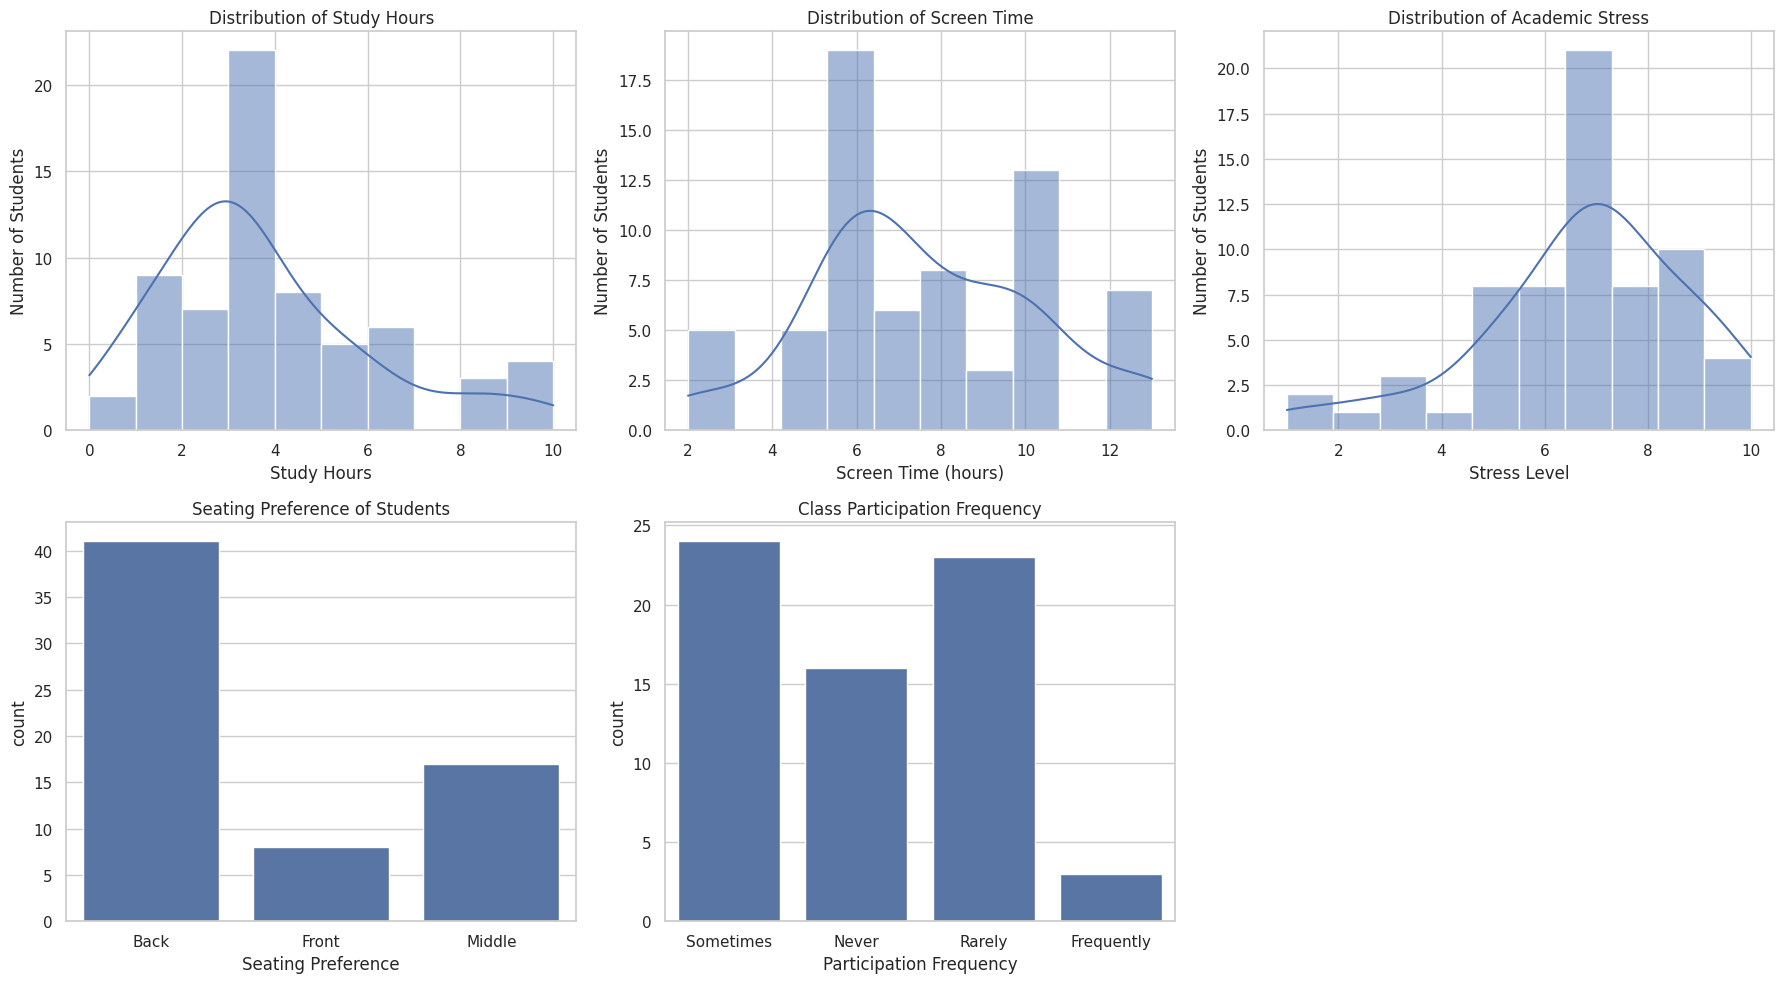

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18,10))

# Study hours histogram + distribution line
sns.histplot(df["study_hours"], bins=10, kde=True, ax=axes[0,0])
axes[0,0].set_title("Distribution of Study Hours")
axes[0,0].set_xlabel("Study Hours")
axes[0,0].set_ylabel("Number of Students")

# Screen time histogram + distribution line
sns.histplot(df["screen_time"], bins=10, kde=True, ax=axes[0,1])
axes[0,1].set_title("Distribution of Screen Time")
axes[0,1].set_xlabel("Screen Time (hours)")
axes[0,1].set_ylabel("Number of Students")

# Academic stress histogram + distribution line
sns.histplot(df["academic_stress"], bins=10, kde=True, ax=axes[0,2])
axes[0,2].set_title("Distribution of Academic Stress")
axes[0,2].set_xlabel("Stress Level")
axes[0,2].set_ylabel("Number of Students")

# Seating preference countplot + line
seating_counts = df["seating_preference"].value_counts()
sns.countplot(x="seating_preference", data=df, ax=axes[1,0])
axes[1,0].set_title("Seating Preference of Students")
axes[1,0].set_xlabel("Seating Preference")

# Class participation countplot + line
participation_counts = df["class_participation"].value_counts()
sns.countplot(x="class_participation", data=df, ax=axes[1,1])
axes[1,1].set_title("Class Participation Frequency")
axes[1,1].set_xlabel("Participation Frequency")

# Empty subplot
axes[1,2].axis("off")

plt.tight_layout()
plt.show()

### 2) Research Question 1 (Classroom Behaviour vs Academic Performance)

Test - 1

In [ ]:
df["attention_category"] = pd.cut(
    df["attention_level"],
    bins=[0,4,7,10],
    labels=["Low","Medium","High"]
)

table_attention = pd.crosstab(df["seating_preference"], df["attention_category"])

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table_attention)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 1.530347660526104
p-value: 0.8212525063414858


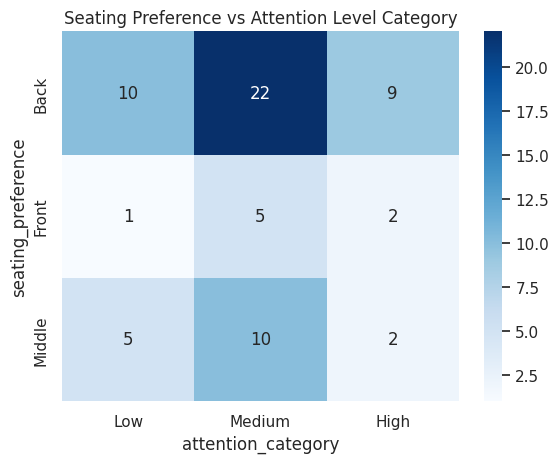

In [ ]:
sns.heatmap(table_attention, annot=True, cmap="Blues")
plt.title("Seating Preference vs Attention Level Category")
plt.show()

Test - 2

In [ ]:
df["cgpa_category"] = pd.cut(
    df["cgpa"],
    bins=[0,7.5,8.5,10],
    labels=["Low","Medium","High"]
)

In [ ]:
table = pd.crosstab(df["class_participation"], df["cgpa_category"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 5.1381486676016825
p-value: 0.5262206997432801


Test - 3 Phone Usage vs Attention

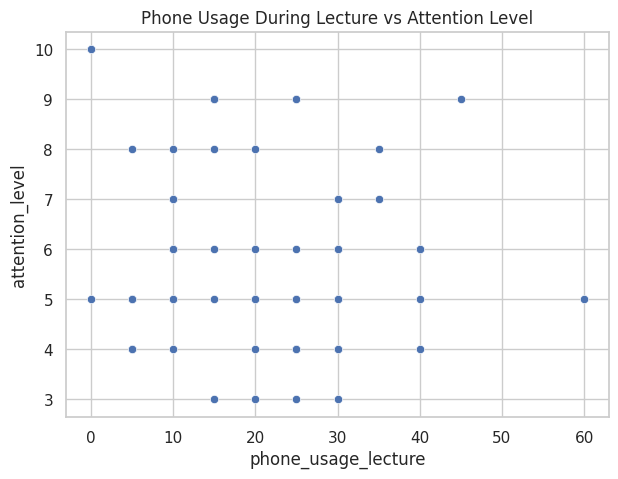

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="phone_usage_lecture",
    y="attention_level",
    data=df
)

plt.title("Phone Usage During Lecture vs Attention Level")

plt.show()

In [ ]:
corr = df["phone_usage_lecture"].corr(df["attention_level"])

print("Correlation:", corr)

Correlation: -0.1621428383720858


Test - 4 Seating Preference vs Participation (Chi-Square Test)

In [ ]:
table_participation = pd.crosstab(df["seating_preference"], df["class_participation"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic:", chi2)
print("p-value:", p)

Chi-Square Statistic: 5.1381486676016825
p-value: 0.5262206997432801


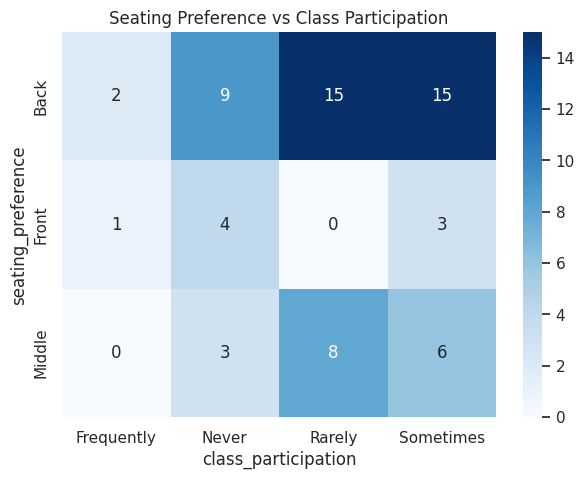

In [ ]:
plt.figure(figsize=(7,5))

sns.heatmap(table_participation, annot=True, cmap="Blues")

plt.title("Seating Preference vs Class Participation")

plt.show()

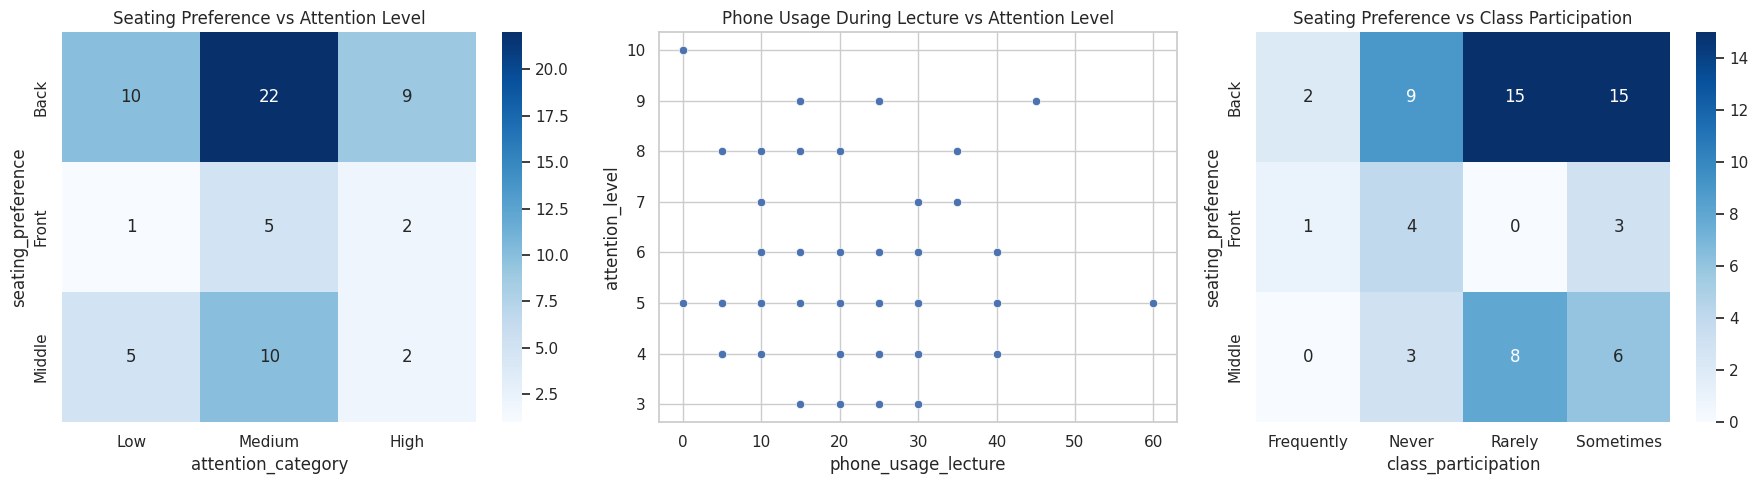

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1️⃣ Seating Preference vs Attention Level
sns.heatmap(table_attention, annot=True, cmap="Blues", ax=axes[0])
axes[0].set_title("Seating Preference vs Attention Level")

# 2️⃣ Phone Usage vs Attention Level
sns.scatterplot(
    x="phone_usage_lecture",
    y="attention_level",
    data=df,
    ax=axes[1]
)
axes[1].set_title("Phone Usage During Lecture vs Attention Level")

# 3️⃣ Seating Preference vs Class Participation
sns.heatmap(table_participation, annot=True, cmap="Blues", ax=axes[2])
axes[2].set_title("Seating Preference vs Class Participation")

plt.tight_layout()
plt.show()

### 3) Research Question - 2 (Lifestyle Habits vs Academic Stress)

Test - 1 Sleep Hours vs Academic Stress

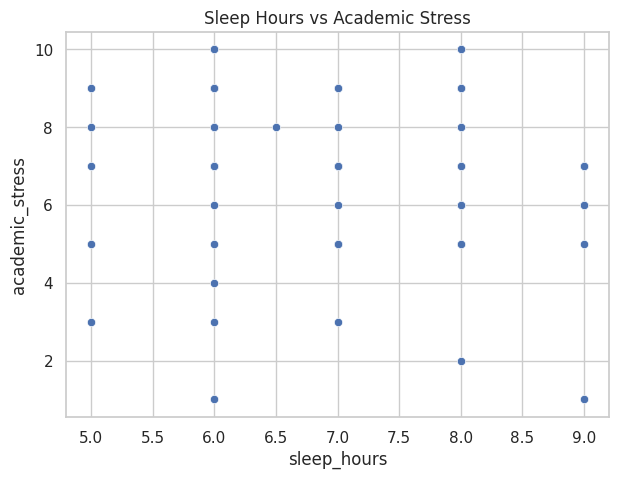

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="sleep_hours",
    y="academic_stress",
    data=df
)

plt.title("Sleep Hours vs Academic Stress")

plt.show()

In [ ]:
corr = df["sleep_hours"].corr(df["academic_stress"])

print("Correlation:", corr)

Correlation: -0.12426316606533953


Test - 2 Screen Time vs Academic Stress

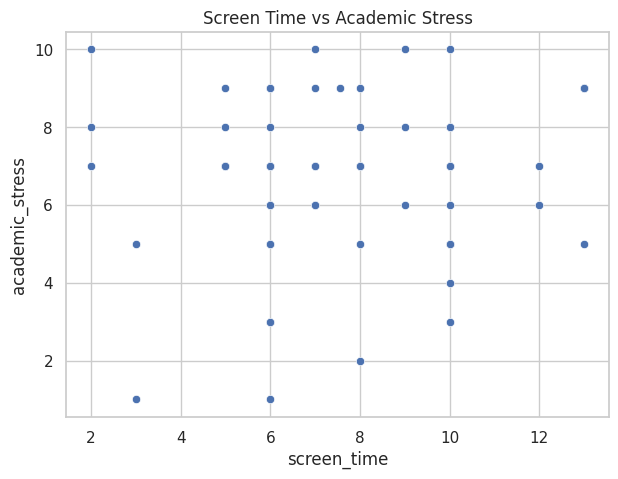

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="screen_time",
    y="academic_stress",
    data=df
)

plt.title("Screen Time vs Academic Stress")

plt.show()

In [ ]:
corr = df["screen_time"].corr(df["academic_stress"])

print("Correlation:", corr)

Correlation: 0.11468669562262321


Test - 3 Assignment Start Time vs Stress

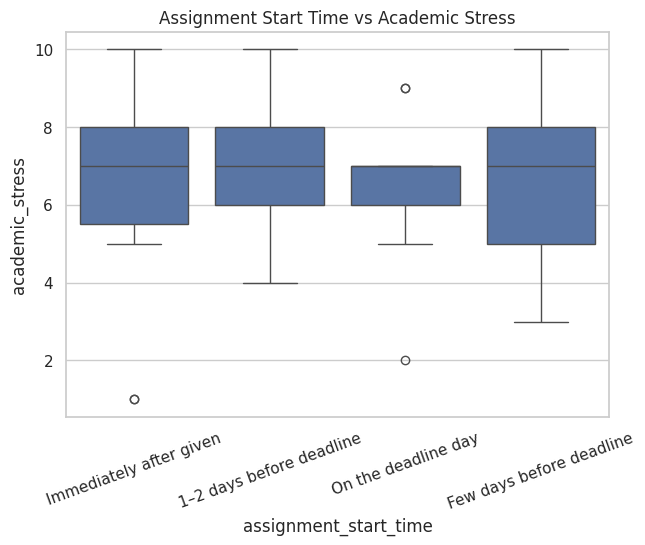

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="assignment_start_time",
    y="academic_stress",
    data=df
)

plt.xticks(rotation=20)

plt.title("Assignment Start Time vs Academic Stress")

plt.show()

In [ ]:
df["stress_category"] = pd.cut(
    df["academic_stress"],
    bins=[0,4,7,10],
    labels=["Low","Medium","High"]
)

In [ ]:
table = pd.crosstab(df["assignment_start_time"], df["stress_category"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 6.232877710524769
p-value: 0.39761516063530483


Test - 4 Student Type vs Sleep Time (Chi-Square)

In [ ]:
table = pd.crosstab(df["student_type"], df["sleep_time"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 3.195238095238096
p-value: 0.7839736099490703
